In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import shap

In [2]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

id_col = 'Id'          # Перевірте назву колонки ID у датасеті
target_col = 'defaulted_on_loan'  # Перевірена назва цільової колонки в train.csv

X = train_df.drop(columns=[id_col, target_col])
y = train_df[target_col]
X_test = test_df.drop(columns=[id_col])

# Категоріальні ознаки
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols:
    X[col] = X[col].astype('category')
    X_test[col] = X_test[col].astype('category')

/tmp/ipykernel_13643/2848332853.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


In [3]:
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

oof_preds = np.zeros(len(train_df))
test_preds = np.zeros(len(test_df))
models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=31,
        random_state=42,
        class_weight='balanced'
    )
    
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    
    val_probs = model.predict_proba(X_va)[:, 1]
    oof_preds[val_idx] = val_probs
    test_preds += model.predict_proba(X_test)[:, 1] / n_splits
    
    fold_auc = roc_auc_score(y_va, val_probs)
    print(f"Fold {fold + 1} ROC AUC: {fold_auc:.5f}")
    models.append(model)

overall_auc = roc_auc_score(y, oof_preds)
print(f"\nOverall Out-of-Fold (OOF) ROC AUC: {overall_auc:.5f}")

/home/codespace/.python/current/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 4010, number of negative: 53718
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003666 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 725
[LightGBM] [Info] Number of data points in the train set: 57728, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Fold 1 ROC AUC: 0.79940
[LightGBM] [Info] Number of positive: 4011, number of negative: 53718
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006346 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 727
[LightGBM] [Info] Number of data points in the train set: 57729, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> init

/home/codespace/.python/current/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2 ROC AUC: 0.81265
[LightGBM] [Info] Number of positive: 4011, number of negative: 53718
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003173 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 725
[LightGBM] [Info] Number of data points in the train set: 57729, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/codespace/.python/current/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3 ROC AUC: 0.80794
[LightGBM] [Info] Number of positive: 4010, number of negative: 53719
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006204 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 734
[LightGBM] [Info] Number of data points in the train set: 57729, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/codespace/.python/current/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 4 ROC AUC: 0.81409
[LightGBM] [Info] Number of positive: 4010, number of negative: 53719
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003188 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 730
[LightGBM] [Info] Number of data points in the train set: 57729, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/codespace/.python/current/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 5 ROC AUC: 0.81871

Overall Out-of-Fold (OOF) ROC AUC: 0.81052



Генерація SHAP values...


/home/codespace/.python/current/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


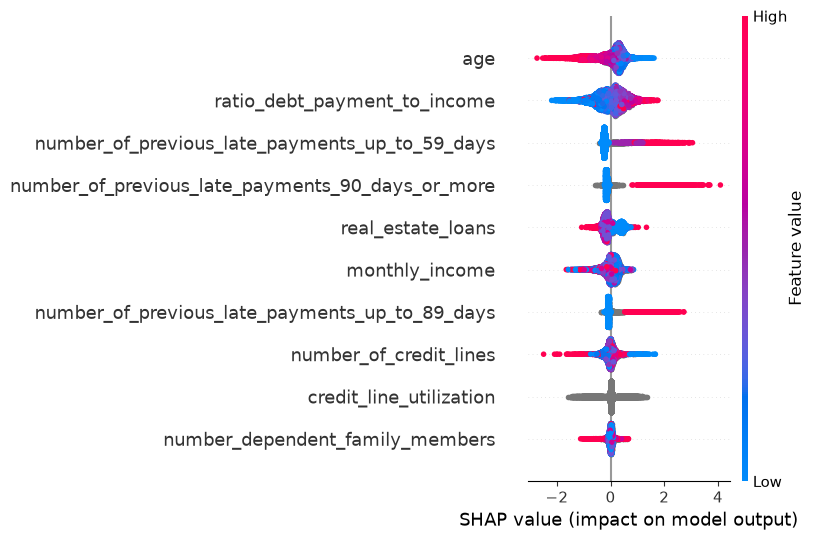

In [4]:
print("\nГенерація SHAP values...")
explainer = shap.TreeExplainer(models[0])
shap_values = explainer.shap_values(X_va)

plt.figure(figsize=(10, 6))
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_va)
else:
    shap.summary_plot(shap_values, X_va)

In [5]:
submission = pd.DataFrame({
    id_col: test_df[id_col],
    'Predicted': test_preds
})

submission.to_csv('submission.csv', index=False)
print("\nФайл 'submission.csv' збережено успішно!")


Файл 'submission.csv' збережено успішно!
